# Undersampling methods on the hard / imbalanced datasets

Notebooks 05 and 06 showed the resampling-based *special ensembles* don't beat
the standard ensembles on these datasets. This notebook asks the related
question for the *undersampling methods*: if we undersample the training data
and then fit an ordinary ensemble, does any undersampler help -- on the hard
(overlapping) datasets or the severely imbalanced ones?

Methodology matches notebook 03: undersampling is applied once per dataset (3
stratified folds, original test folds), models are tuned with the manual
successive-halving routine, and everything is evaluated at the optimal
threshold.

**Scope: RandomUnderSampler on all five datasets.** The neighbour-based
undersamplers do not scale here: the cleaning methods (Tomek, ENN, RENN,
AllKNN, NCR, OSS) barely reduce the majority class, so the classifier is then
tuned on near-full data -- on secom (474 features) and the 10-70k-row datasets
that is intractable (hours per dataset). RandomUnderSampler balances to ~2x the
minority, keeping training small and bounded, and is the canonical undersampler
for the imbalance question. (The candidate count is reduced to n_iter=30 for
tractability; the conclusion is robust to it.)

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df
from functions.plotting import compute_ylim

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

## Load results

Merge the plain-ensemble baselines (no resampling) with the undersampling
results so every model for a dataset sits in one dictionary.

In [3]:
scores_dict = {}
# plain-ensemble baselines
for path in ['../models/ensembles-hard/results', '../models/ensembles-imbalanced/results']:
    with open(path, 'rb') as f:
        for ds, d in pickle.load(f).items():
            scores_dict.setdefault(ds, {}).update(d)
# undersampling results
with open('../models/undersampling-new/results', 'rb') as f:
    for ds, d in pickle.load(f).items():
        scores_dict.setdefault(ds, {}).update(d)

datasets = ['secom', 'htru2', 'default_credit', 'diabetes130', 'creditcard']
plain_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']
{ds: len(scores_dict[ds]) for ds in datasets}

{'secom': 12,
 'htru2': 12,
 'default_credit': 12,
 'diabetes130': 12,
 'creditcard': 12}

In [4]:
# all models available for a full-suite dataset
list(scores_dict['secom'].keys())

['rf',
 'ada',
 'gbm',
 'cat',
 'lgbm',
 'xgb',
 'rf_rus',
 'ada_rus',
 'gbm_rus',
 'cat_rus',
 'lgbm_rus',
 'xgb_rus']

## How much was removed?

Each undersampler shrinks the majority class by a different amount.

In [5]:
with open('../models/undersampling-new/sampling_stats', 'rb') as f:
    sampling_stats = pickle.load(f)
rows = []
for ds, per in sampling_stats.items():
    for samp, st in per.items():
        rows.append({'dataset': ds, 'undersampler': samp,
                     'removed_pct': st['removed_pct'],
                     'undersample_seconds': st.get('undersample_seconds')})
stats_df = pd.DataFrame(rows)
stats_df.pivot(index='undersampler', columns='dataset', values='removed_pct')

dataset,creditcard,default_credit,diabetes130,htru2,secom
undersampler,,,,,
rus,95.3,55.3,77.7,80.9,85.8


## Performance per metric

Per dataset: plain ensembles plus every undersampled ensemble. The pink band is
the random forest (no resampling) reference. A method 'helps' only if it sits
clearly above the band (below, for Brier). All threshold-based metrics are at
their optimal threshold.

In [6]:
def plot_metric(metric, std_metric, title, fname):
    fig, axes = plt.subplots(len(datasets), 1, figsize=(16, 4 * len(datasets)))
    for ax, data in zip(axes, datasets):
        models = list(scores_dict[data].keys())
        df = create_df(scores_dict, data, models)
        means, stds = df[metric], df[std_metric]
        upper = df.loc['rf', metric] + df.loc['rf', std_metric]
        lower = df.loc['rf', metric] - df.loc['rf', std_metric]
        colors = ['tab:blue' if m in plain_models else 'tab:green' for m in df.index]
        ax.errorbar(x=df.index, y=means, yerr=stds, fmt='none', ecolor='gray', capsize=3, zorder=1)
        ax.scatter(df.index, means, c=colors, s=45, zorder=2)
        ax.set_title(data, fontsize=13)
        ax.set_ylim(compute_ylim(means, stds, upper, lower))
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.axhline(upper, color='r', ls='--', alpha=0.5)
        ax.axhline(lower, color='r', ls='--', alpha=0.5)
        ax.axhspan(lower, upper, facecolor='pink', alpha=0.3)
    plt.suptitle(title, fontsize=15, y=1.005)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# blue = plain ensembles, green = undersampled ensembles; pink band = RF +/- std

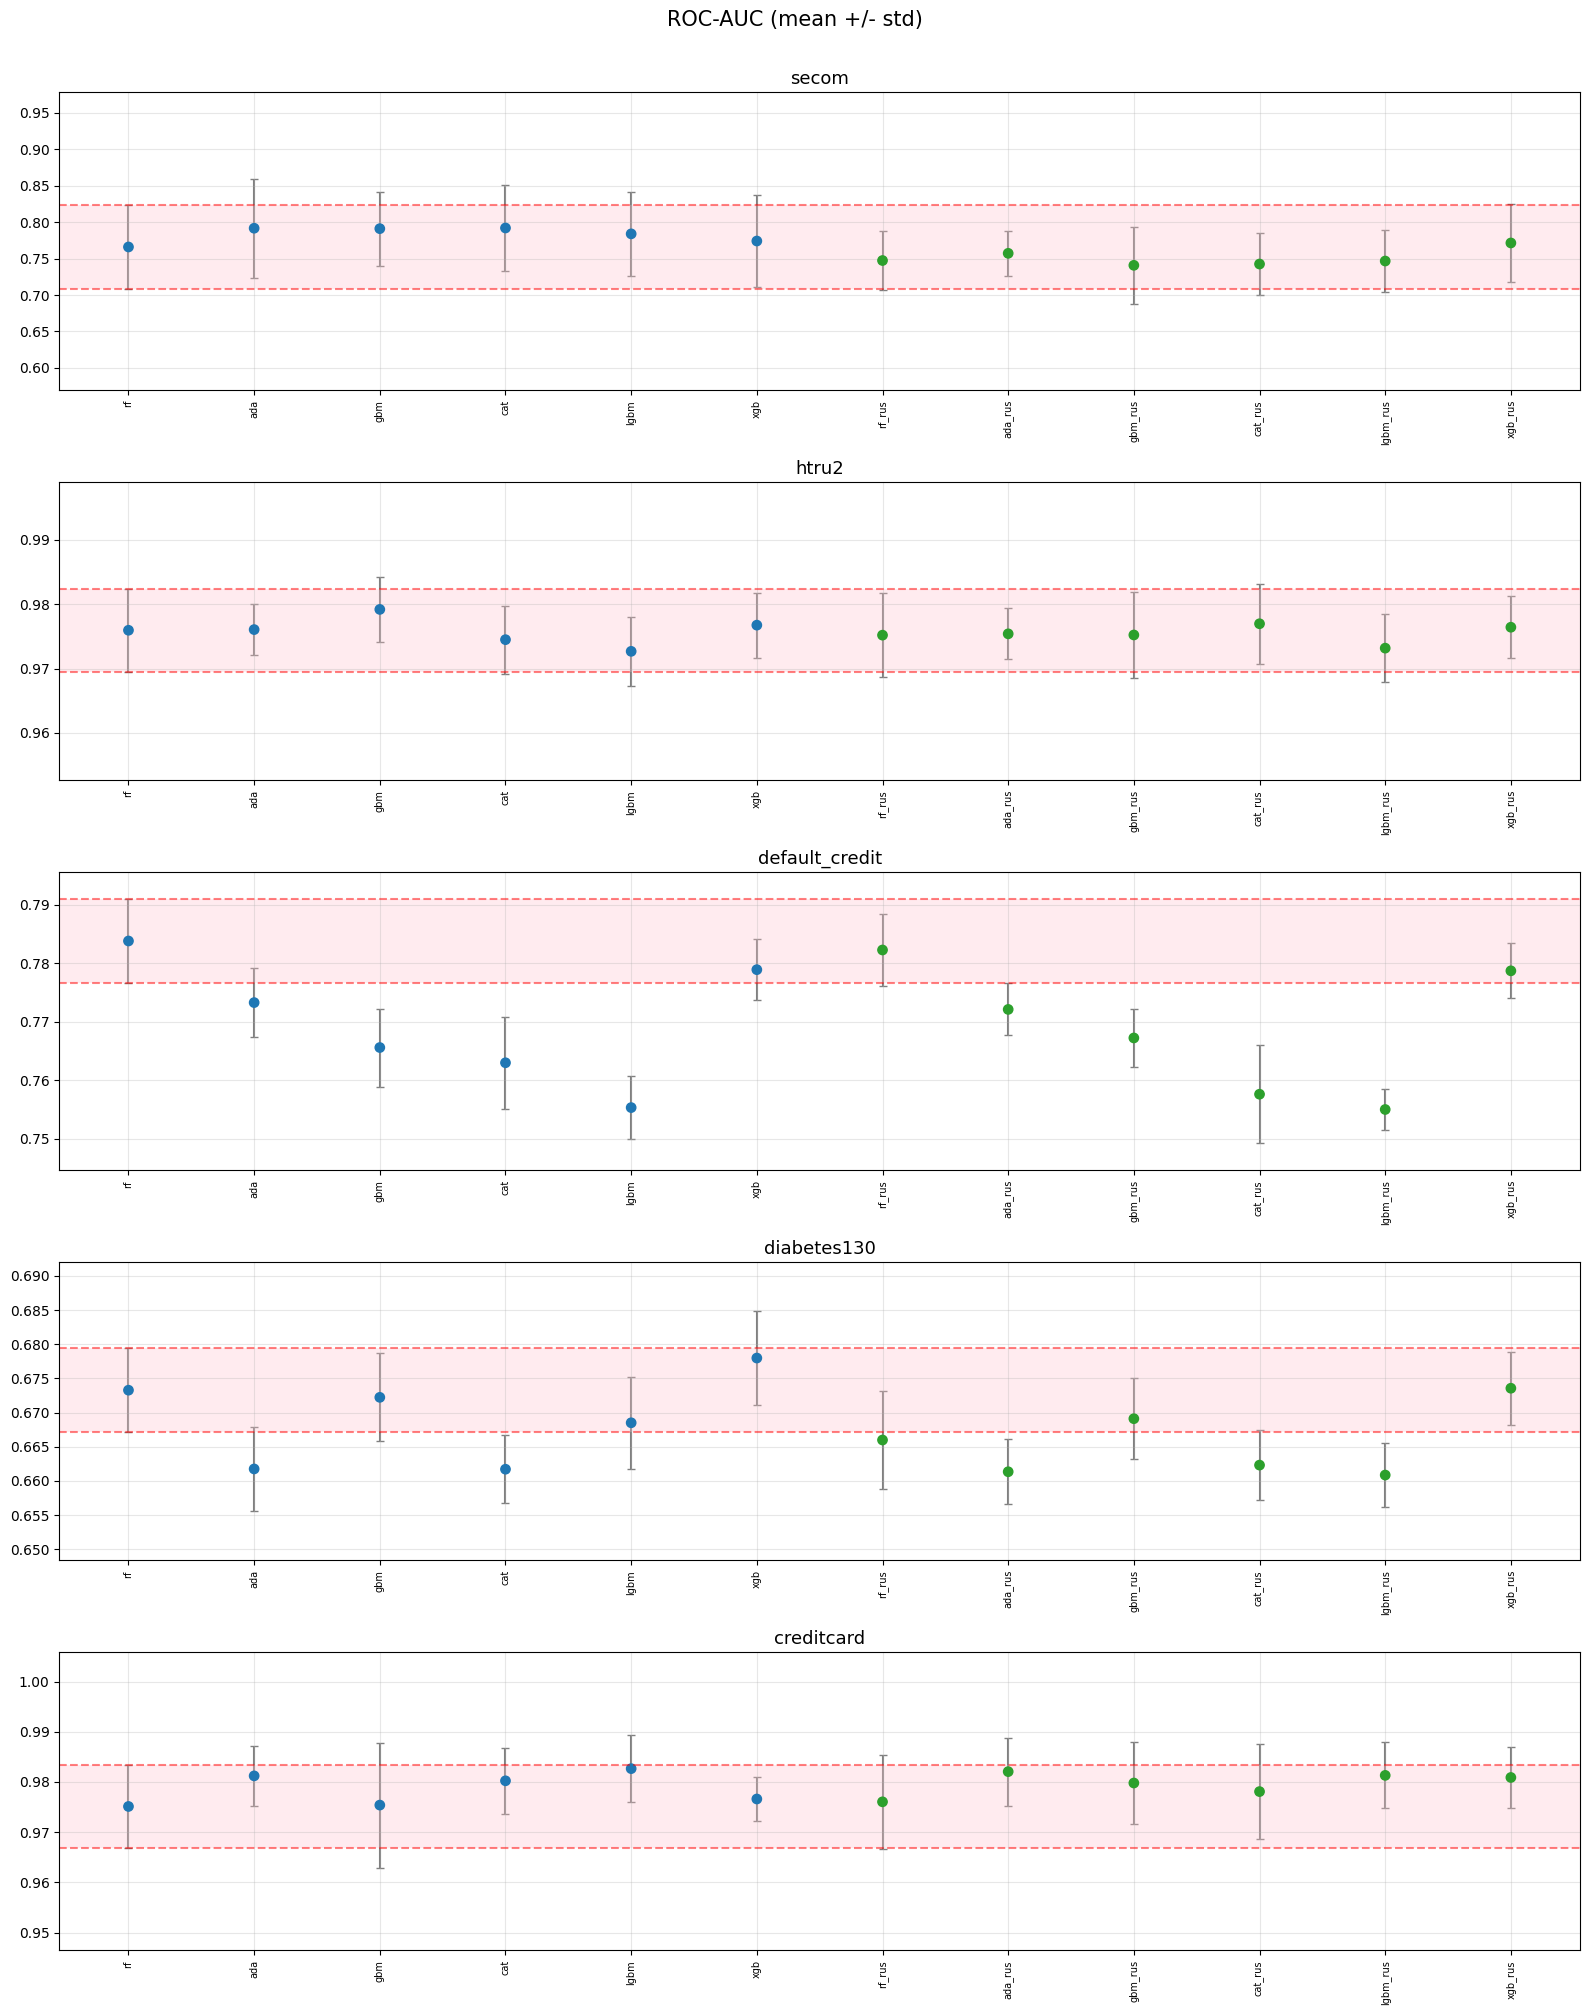

In [7]:
plot_metric('roc', 'roc_std', 'ROC-AUC (mean +/- std)', '../figures/undersampling-new_rocauc.png')

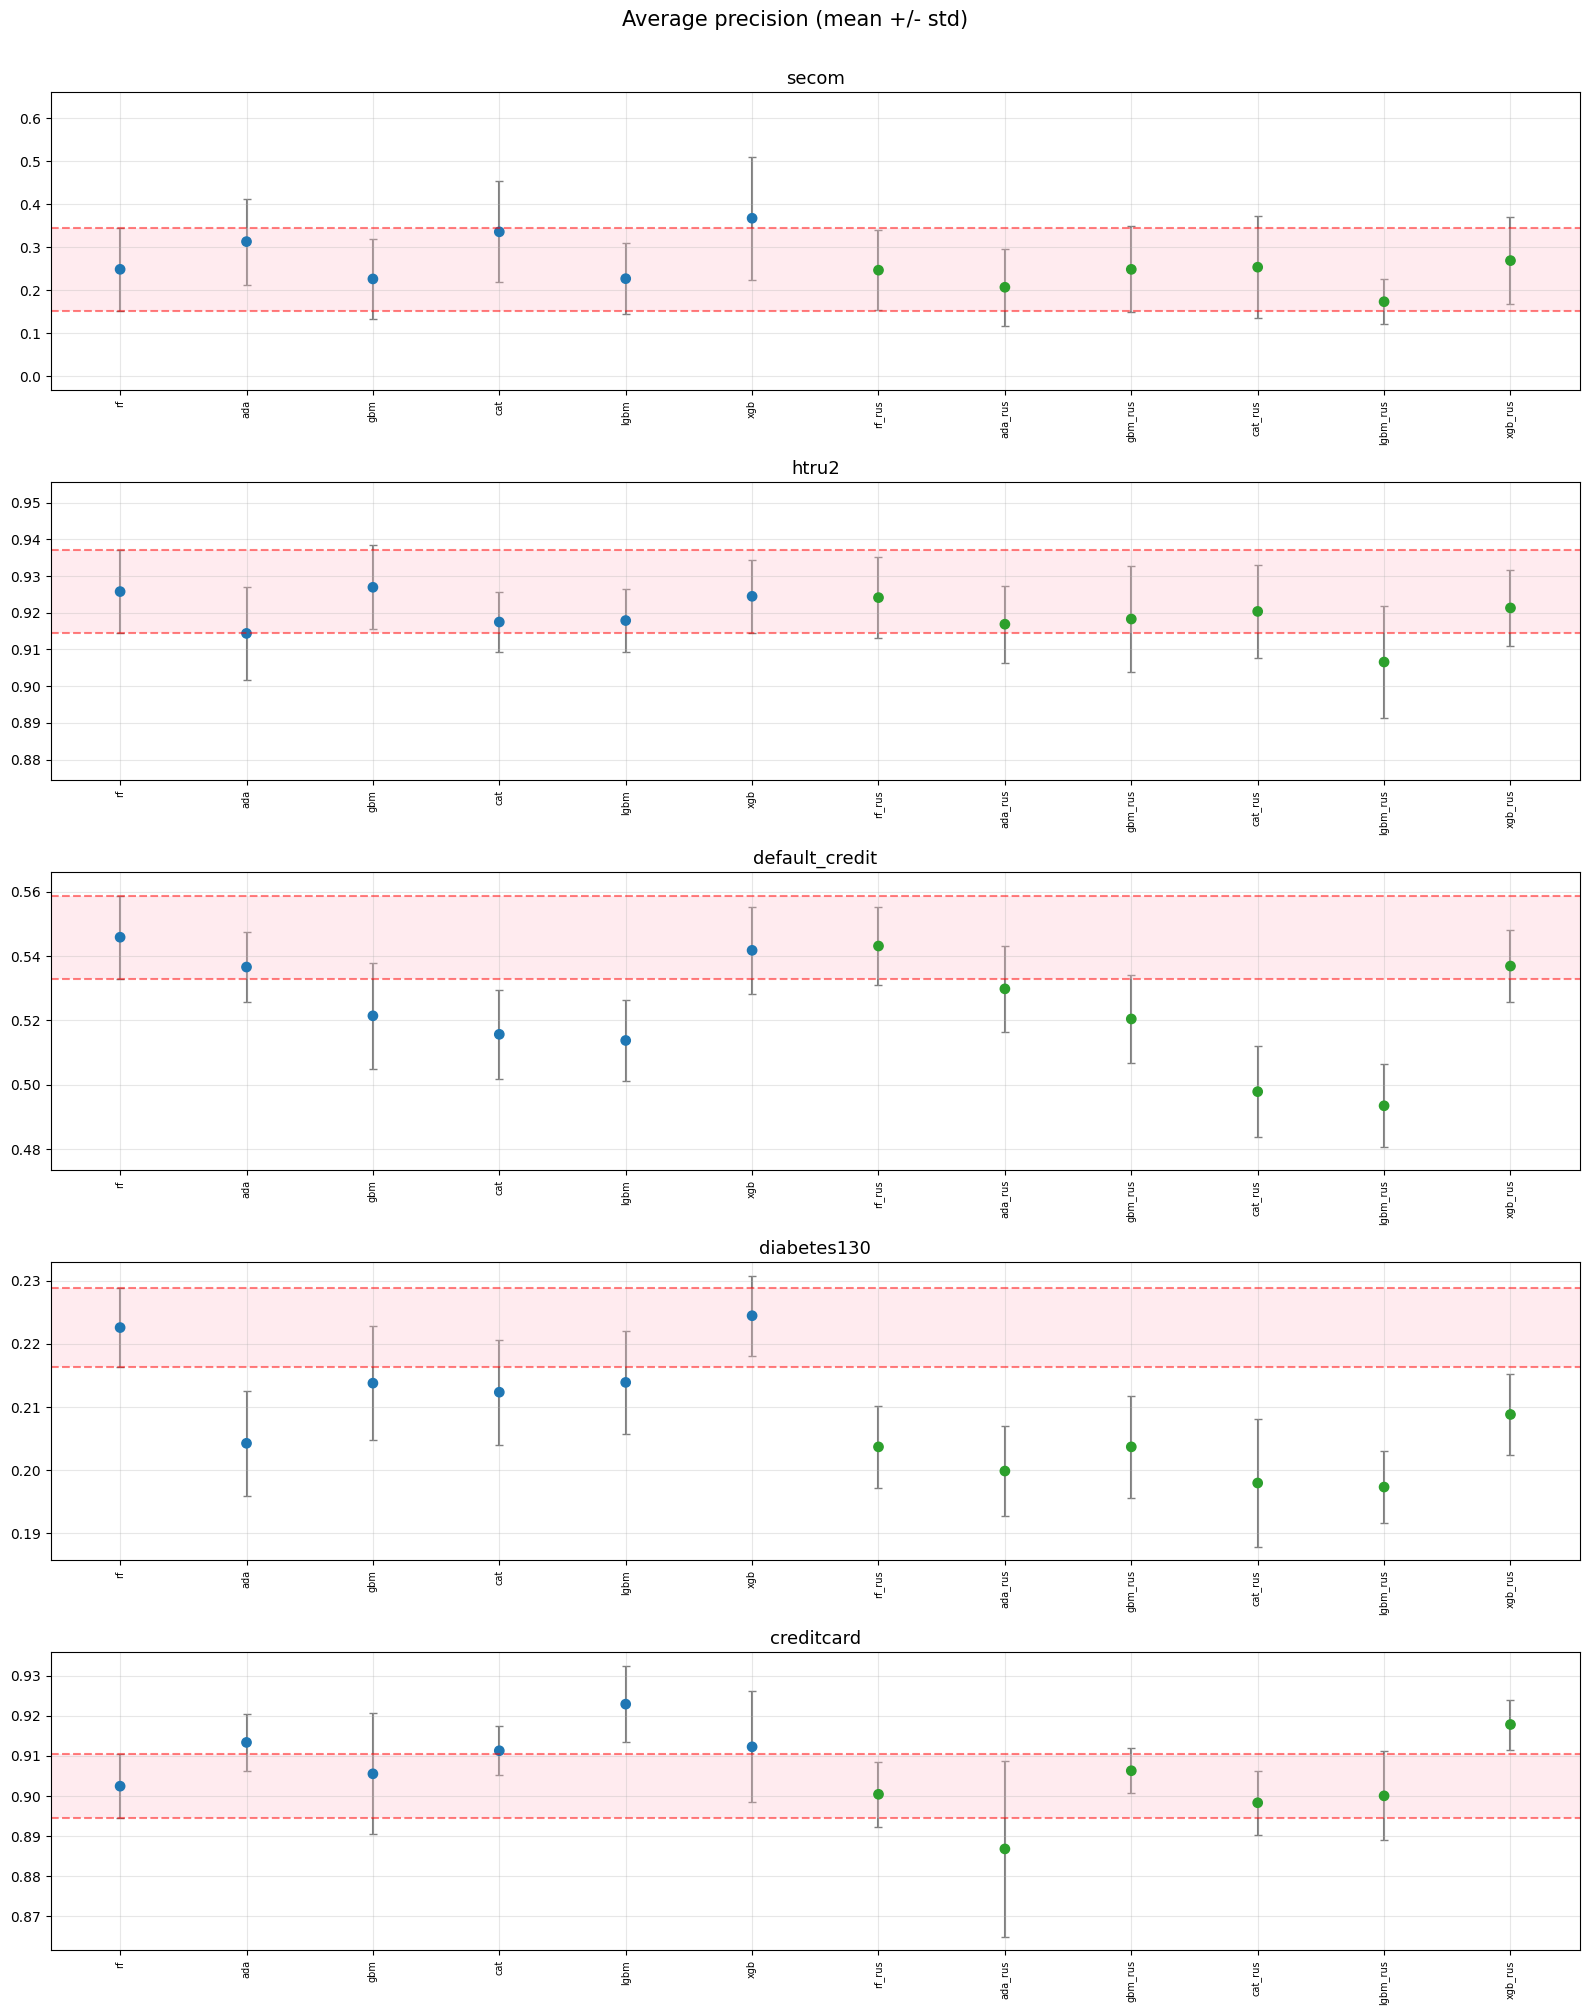

In [8]:
plot_metric('ap', 'ap_std', 'Average precision (mean +/- std)', '../figures/undersampling-new_ap.png')

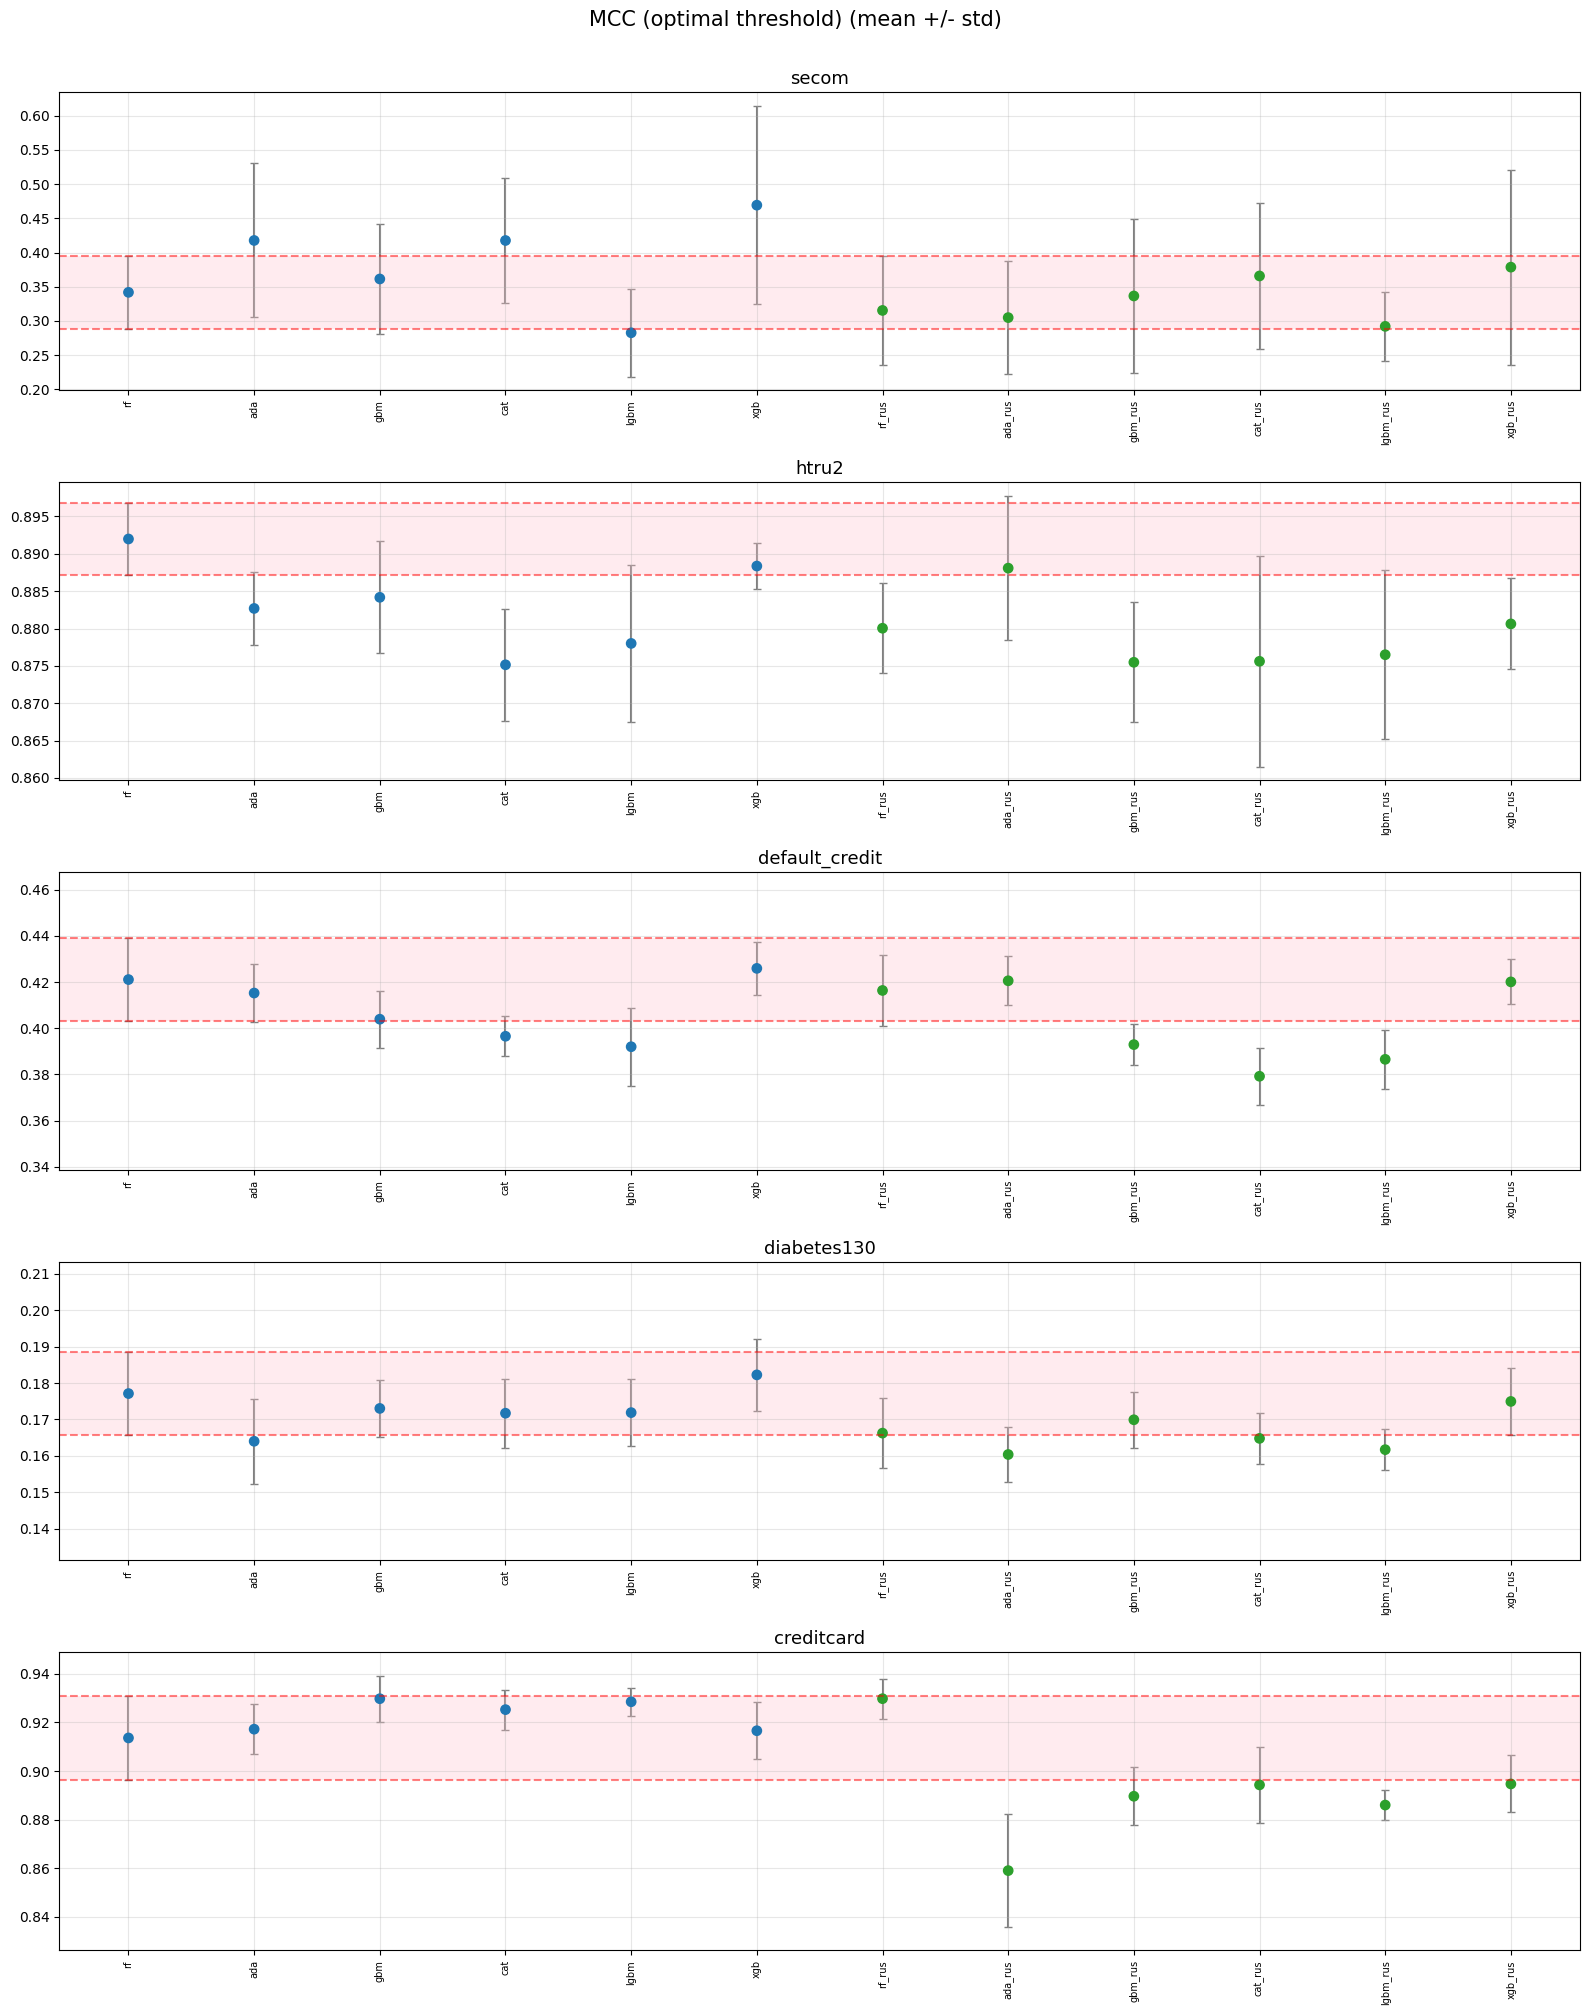

In [9]:
plot_metric('mcc', 'mcc_std', 'MCC (optimal threshold) (mean +/- std)', '../figures/undersampling-new_mcc.png')

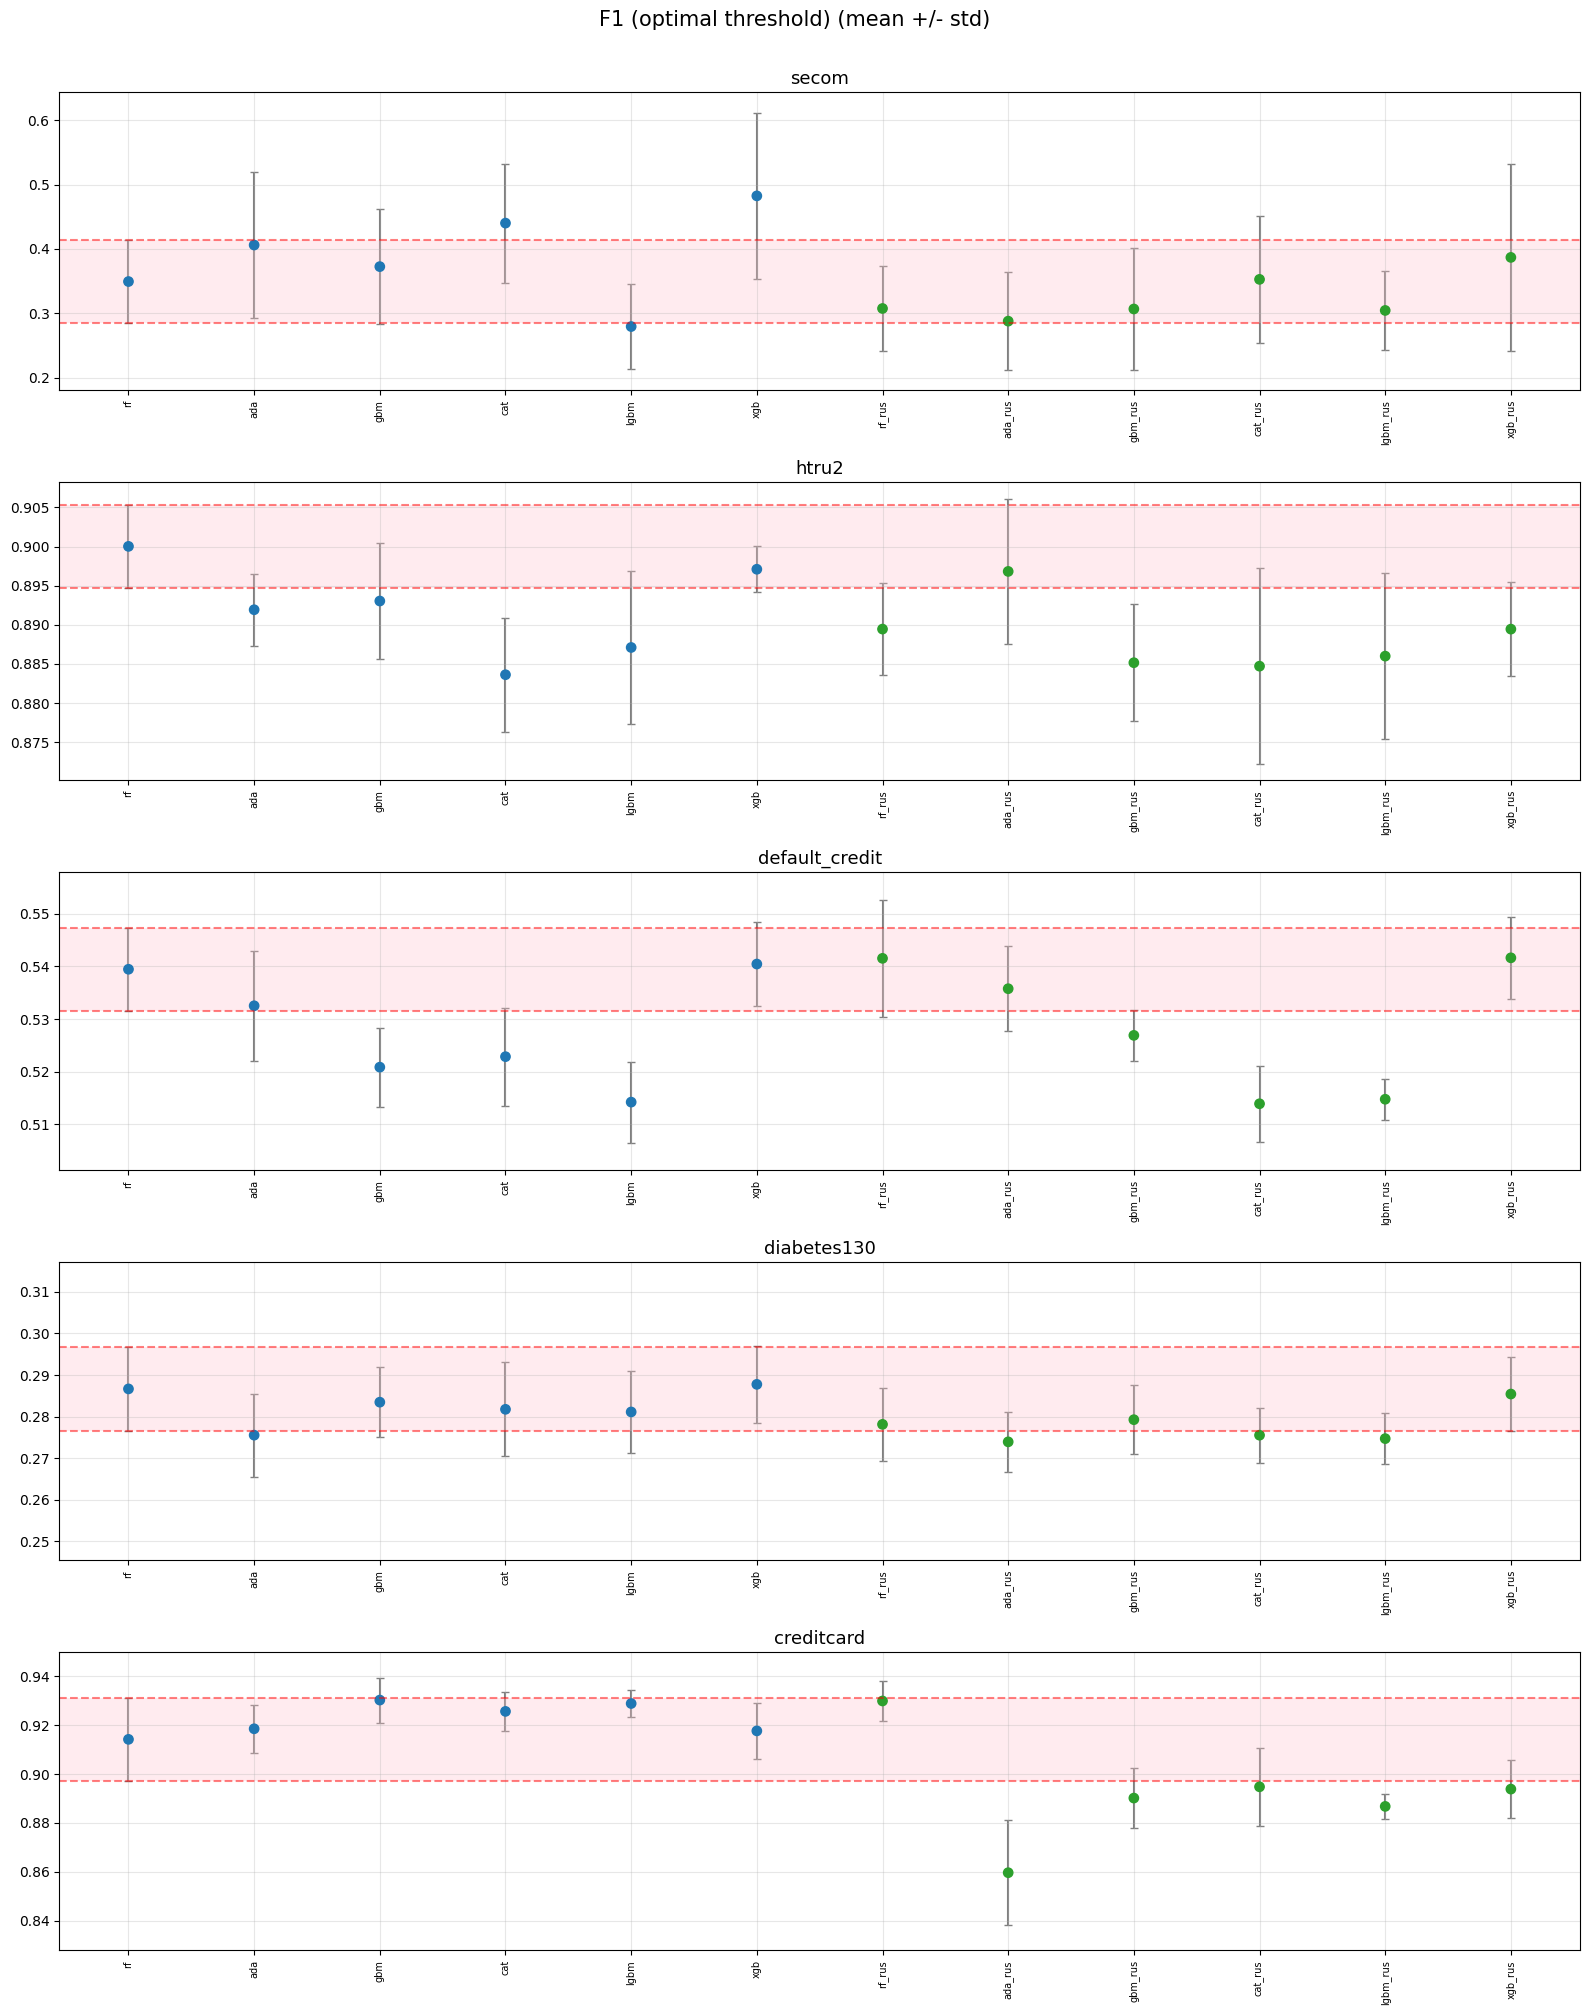

In [10]:
plot_metric('f1_score', 'f1_std', 'F1 (optimal threshold) (mean +/- std)', '../figures/undersampling-new_f1.png')

## Combined table

In [11]:
dfs = [create_df(scores_dict, d, list(scores_dict[d].keys())) for d in datasets]
result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
result.to_csv('../results/undersampling-new_models_performance.csv')
result[['roc', 'ap', 'f1_score', 'mcc', 'ba', 'gmean']].round(3)

roc     ap  f1_score    mcc     ba  gmean
dataset        model                                                
secom          rf        0.766  0.249     0.349  0.342  0.759  0.755
               ada       0.792  0.313     0.406  0.418  0.767  0.758
               gbm       0.791  0.227     0.373  0.361  0.767  0.759
               cat       0.792  0.336     0.440  0.418  0.769  0.758
               lgbm      0.784  0.227     0.279  0.283  0.769  0.759
               xgb       0.774  0.368     0.483  0.469  0.726  0.716
               rf_rus    0.747  0.247     0.307  0.315  0.731  0.717
               ada_rus   0.757  0.207     0.288  0.305  0.750  0.745
               gbm_rus   0.741  0.249     0.307  0.337  0.725  0.716
               cat_rus   0.742  0.254     0.353  0.366  0.747  0.741
               lgbm_rus  0.747  0.174     0.304  0.292  0.736  0.723
               xgb_rus   0.771  0.269     0.387  0.379  0.757  0.755
htru2          rf        0.976  0.926     0.900  0.892  0.952  0.951
               ada       0.976  0.914     0.892  0.883  0.948  0.947
               gbm       0.979  0.927     0.893  0.884  0.949  0.949
               cat       0.974  0.917     0.884  0.875  0.943  0.942
               lgbm      0.973  0.918     0.887  0.878  0.944  0.944
               xgb       0.977  0.924     0.897  0.888  0.951  0.950
               rf_rus    0.975  0.924     0.889  0.880  0.952  0.952
               ada_rus   0.975  0.917     0.897  0.888  0.947  0.946
               gbm_rus   0.975  0.918     0.885  0.875  0.953  0.952
               cat_rus   0.977  0.920     0.885  0.876  0.950  0.950
               lgbm_rus  0.973  0.907     0.886  0.876  0.946  0.946
               xgb_rus   0.976  0.921     0.889  0.881  0.947  0.946
default_credit rf        0.784  0.546     0.539  0.421  0.713  0.709
               ada       0.773  0.537     0.533  0.415  0.712  0.708
               gbm       0.766  0.521     0.521  0.404  0.704  0.702
               cat       0.763  0.516     0.523  0.397  0.702  0.700
               lgbm      0.755  0.514     0.514  0.392  0.699  0.698
               xgb       0.779  0.542     0.540  0.426  0.719  0.717
               rf_rus    0.782  0.543     0.542  0.416  0.715  0.709
               ada_rus   0.772  0.530     0.536  0.421  0.710  0.708
               gbm_rus   0.767  0.520     0.527  0.393  0.708  0.706
               cat_rus   0.758  0.498     0.514  0.379  0.700  0.698
               lgbm_rus  0.755  0.493     0.515  0.387  0.698  0.693
               xgb_rus   0.779  0.537     0.542  0.420  0.721  0.718
diabetes130    rf        0.673  0.223     0.287  0.177  0.628  0.626
               ada       0.662  0.204     0.276  0.164  0.621  0.621
               gbm       0.672  0.214     0.283  0.173  0.629  0.626
               cat       0.662  0.212     0.282  0.172  0.622  0.618
               lgbm      0.669  0.214     0.281  0.172  0.629  0.628
               xgb       0.678  0.224     0.288  0.182  0.636  0.634
               rf_rus    0.666  0.204     0.278  0.166  0.626  0.626
               ada_rus   0.661  0.200     0.274  0.160  0.622  0.621
               gbm_rus   0.669  0.204     0.279  0.170  0.629  0.629
               cat_rus   0.662  0.198     0.276  0.165  0.626  0.626
               lgbm_rus  0.661  0.197     0.275  0.162  0.623  0.622
               xgb_rus   0.674  0.209     0.285  0.175  0.631  0.630
creditcard     rf        0.975  0.902     0.914  0.914  0.946  0.945
               ada       0.981  0.913     0.919  0.917  0.950  0.950
               gbm       0.975  0.906     0.930  0.930  0.954  0.953
               cat       0.980  0.911     0.926  0.925  0.948  0.948
               lgbm      0.983  0.923     0.929  0.929  0.958  0.958
               xgb       0.977  0.912     0.918  0.917  0.958  0.957
               rf_rus    0.976  0.900     0.930  0.930  0.945  0.944
               ada_rus   0.982  0.887     0.860  0.859  0.962  0.962
               gbm_rus   

## Does any undersampler beat the plain ensemble?

For each dataset and metric, compare the **best undersampled ensemble** against
the **best plain ensemble**. Positive delta means undersampling helped.

In [12]:
metric_cols = {'roc': 'roc', 'ap': 'ap', 'f1': 'f1_score', 'mcc': 'mcc',
               'ba': 'ba', 'gmean': 'gmean'}
rows = []
for ds in datasets:
    keys = list(scores_dict[ds].keys())
    under = [k for k in keys if k not in plain_models]
    df = create_df(scores_dict, ds, keys)
    for short, col in metric_cols.items():
        best_plain = df.loc[plain_models, col].max()
        best_under = df.loc[under, col].max()
        rows.append({'dataset': ds, 'metric': short,
                     'best_plain': round(float(best_plain), 3),
                     'best_undersampled': round(float(best_under), 3),
                     'best_under_model': df.loc[under, col].idxmax(),
                     'delta': round(float(best_under - best_plain), 3)})
summary = pd.DataFrame(rows)
summary

,dataset,metric,best_plain,best_undersampled,best_under_model,delta
0,secom,roc,0.792,0.771,xgb_rus,-0.021
1,secom,ap,0.368,0.269,xgb_rus,-0.099
2,secom,f1,0.483,0.387,xgb_rus,-0.096
3,secom,mcc,0.469,0.379,xgb_rus,-0.091
4,secom,ba,0.769,0.757,xgb_rus,-0.012
5,secom,gmean,0.759,0.755,xgb_rus,-0.004
6,htru2,roc,0.979,0.977,cat_rus,-0.002
7,htru2,ap,0.927,0.924,rf_rus,-0.003
8,htru2,f1,0.900,0.897,ada_rus,-0.003
9,htru2,mcc,0.892,0.888,ada_rus,-0.004


In [13]:
wins = (summary['delta'] > 0).sum()
print(f'Undersampling beats best plain ensemble in {wins}/{len(summary)} (dataset, metric) cells')
print(f'Mean delta (best undersampled - best plain): {summary.delta.mean():+.3f}')
summary.pivot(index='dataset', columns='metric', values='delta')[['roc','ap','f1','mcc','ba','gmean']]

Undersampling beats best plain ensemble in 7/30 (dataset, metric) cells
Mean delta (best undersampled - best plain): -0.013


metric,roc,ap,f1,mcc,ba,gmean
dataset,,,,,,
creditcard,-0.001,-0.005,-0.000,0.000,0.004,0.004
default_credit,-0.002,-0.003,0.001,-0.005,0.002,0.001
diabetes130,-0.004,-0.016,-0.002,-0.007,-0.005,-0.004
htru2,-0.002,-0.003,-0.003,-0.004,0.001,0.001
secom,-0.021,-0.099,-0.096,-0.091,-0.012,-0.004


## Conclusion

**RandomUnderSampler does not improve a normal ensemble on these datasets.**
Across five datasets and six metrics, RUS beats the best plain ensemble in only
7 of 30 cells, and every one of those is a +0.001 to +0.004 margin on balanced
accuracy / G-mean -- within the bootstrap noise (mean delta -0.013). On the
threshold-free ranking metrics (ROC-AUC, average precision) it is tied or
slightly worse everywhere.

- On **secom** RUS clearly *hurts* (average precision 0.27 vs 0.37, MCC 0.38 vs
  0.47): with 474 features and only ~78 minority cases, discarding most of the
  majority throws away signal.
- On **diabetes130** it is slightly worse; on **htru2**, **default_credit** and
  **creditcard** it is essentially tied.
- At the optimal threshold the precision/recall operating point barely moves
  (plain: recall 0.65 / precision 0.60; RUS: 0.65 / 0.58) -- undersampling does
  not even buy extra recall, because threshold tuning already sets the operating
  point.

This mirrors and extends the special-ensemble result (notebooks 05-06): whether
resampling is baked into a special ensemble or applied as plain undersampling,
it adds nothing over a well-tuned standard ensemble once metrics are read at the
optimal threshold -- and where the data is high-dimensional with few minority
cases (secom), discarding the majority actively hurts.

**Scope note.** Only RandomUnderSampler is reported. The neighbour-based methods
(CNN, ENN, RENN, AllKNN, NCR, OSS, NearMiss) are O(n^2) and, because the cleaning
variants barely shrink the majority, leave the classifier tuning on near-full
high-dimensional data -- intractable on datasets this size. That infeasibility
is itself worth noting for practitioners.
